# EDA: `geolocation`

Разведочный анализ таблицы `geolocation` из базы данных Olist.


### Импорты

In [1]:
import pandas as pd

import matplotlib.pyplot as plt

from sqlalchemy import create_engine
from sqlalchemy.engine import URL

In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

True

### Конфигурация

In [3]:
USERNAME = os.getenv("DB_USERNAME")
PASSWORD = os.getenv("DB_PASSWORD")
HOST = os.getenv("DB_HOST")
PORT = os.getenv("DB_PORT")
DATABASE = os.getenv("DB_NAME")

url = URL.create(
    drivername="postgresql+psycopg2",
    username=USERNAME,
    password=PASSWORD,
    host=HOST,
    port=PORT,
    database=DATABASE,
)

In [4]:
connection = create_engine(url=url)

## Анализ данных


In [5]:
read_sql_query = "SELECT * FROM geolocation"
df = pd.read_sql(sql=read_sql_query, con=connection)

In [6]:
df.head()

,geolocation_id,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1,01037,-23.545621,-46.639292,sao paulo,SP
1,2,01046,-23.546081,-46.644820,sao paulo,SP
2,3,01046,-23.546129,-46.642951,sao paulo,SP
3,4,01041,-23.544392,-46.639499,sao paulo,SP
4,5,01035,-23.541578,-46.641607,sao paulo,SP


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 6 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_id               1000163 non-null  int64  
 1   geolocation_zip_code_prefix  1000163 non-null  str    
 2   geolocation_lat              1000163 non-null  float64
 3   geolocation_lng              1000163 non-null  float64
 4   geolocation_city             1000163 non-null  str    
 5   geolocation_state            1000163 non-null  str    
dtypes: float64(2), int64(1), str(3)
memory usage: 45.8 MB


In [8]:
df.describe(include='all')

,geolocation_id,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,1.000163e+06,1000163,1.000163e+06,1.000163e+06,1000163,1000163
unique,NaN,19015,NaN,NaN,5968,27
top,NaN,24220,NaN,NaN,sao paulo,SP
freq,NaN,1146,NaN,NaN,160718,404268
mean,5.000820e+05,NaN,-2.117615e+01,-4.639054e+01,NaN,NaN
std,2.887223e+05,NaN,5.715866e+00,4.269748e+00,NaN,NaN
min,1.000000e+00,NaN,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,2.500415e+05,NaN,-2.360355e+01,-4.857317e+01,NaN,NaN
50%,5.000820e+05,NaN,-2.291938e+01,-4.663788e+01,NaN,NaN
75%,7.501225e+05,NaN,-1.997962e+01,-4.376771e+01,NaN,NaN


In [9]:
df.memory_usage(deep=True)

Index                               132
geolocation_id                  8001304
geolocation_zip_code_prefix    54008802
geolocation_lat                 8001304
geolocation_lng                 8001304
geolocation_city               59477958
geolocation_state              51008313
dtype: int64

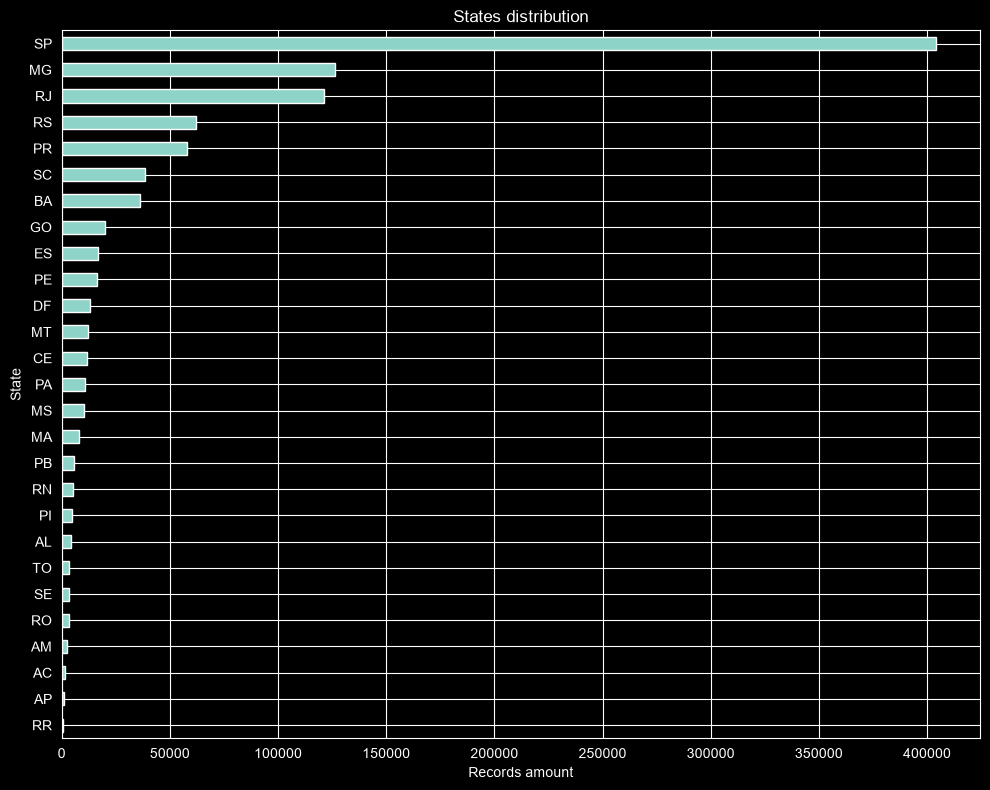

In [10]:
state_counts = df["geolocation_state"].value_counts()

plt.figure(figsize=(10, 8))

state_counts.sort_values().plot.barh()

plt.xlabel("Records amount")
plt.ylabel("State")
plt.title("States distribution")

plt.tight_layout()
plt.show()

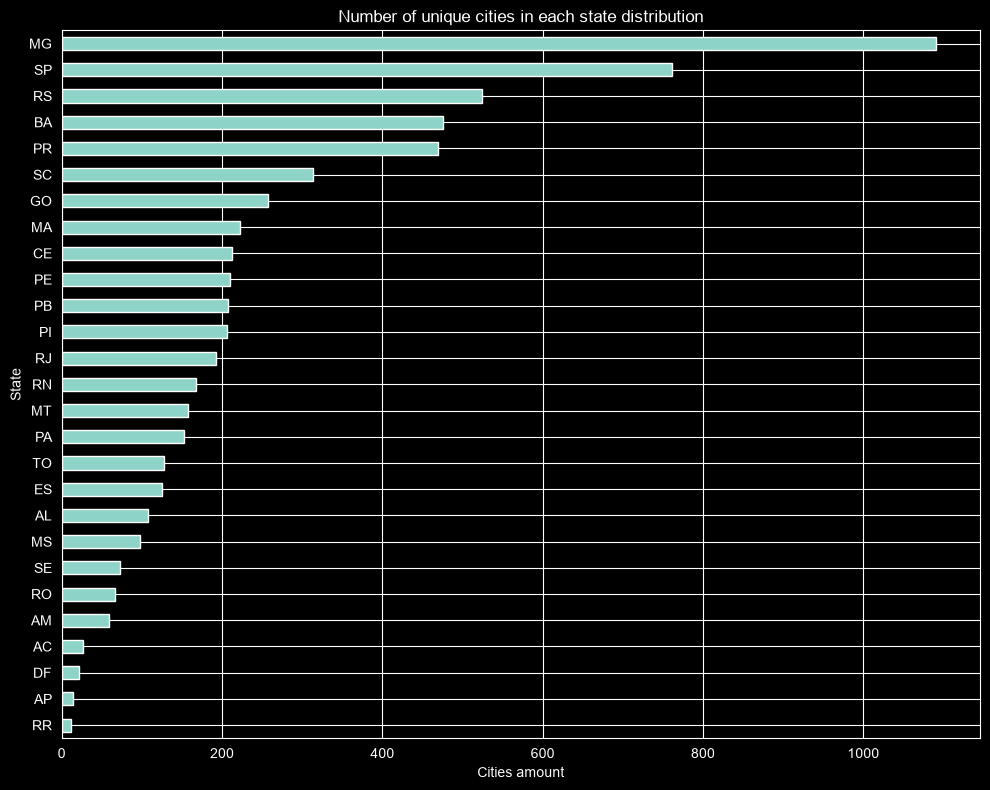

In [11]:
cities_by_state = (
    df.groupby("geolocation_state")["geolocation_city"]
    .nunique()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

cities_by_state.sort_values().plot.barh()

plt.xlabel("Cities amount")
plt.ylabel("State")
plt.title("Number of unique cities in each state distribution")

plt.tight_layout()
plt.show()

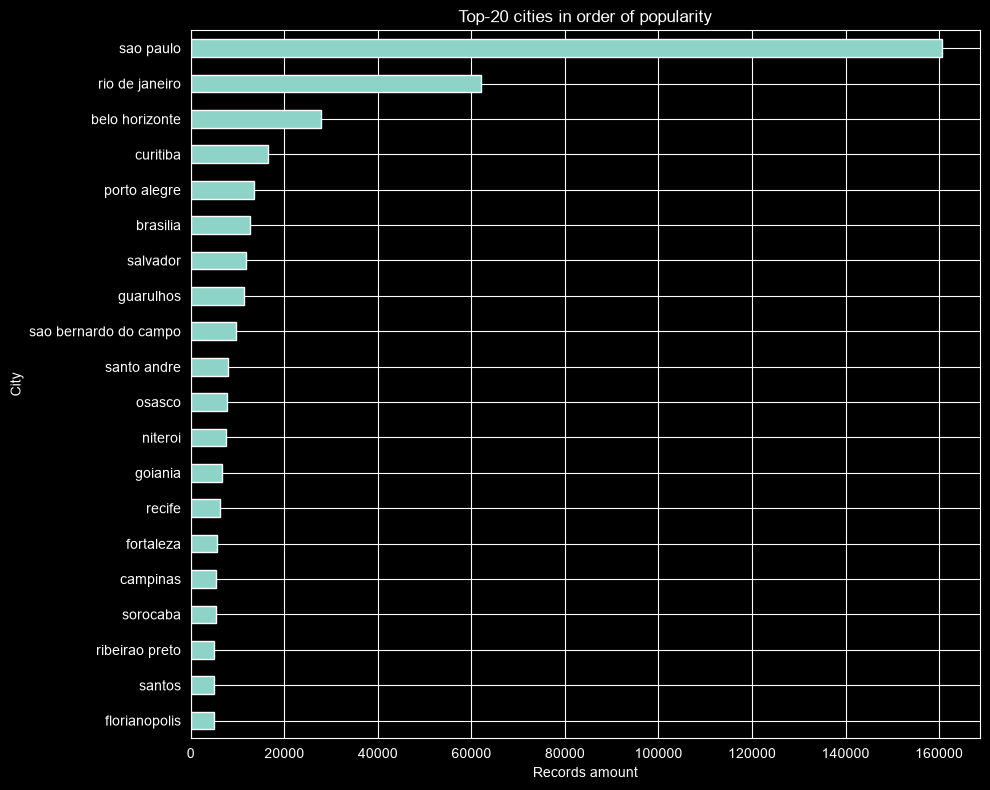

In [12]:
top_cities = (
    df["geolocation_city"]
    .value_counts()
    .head(20)
)

plt.figure(figsize=(10, 8))

top_cities.sort_values().plot.barh()

plt.xlabel("Records amount")
plt.ylabel("City")
plt.title("Top-20 cities in order of popularity")

plt.tight_layout()
plt.show()

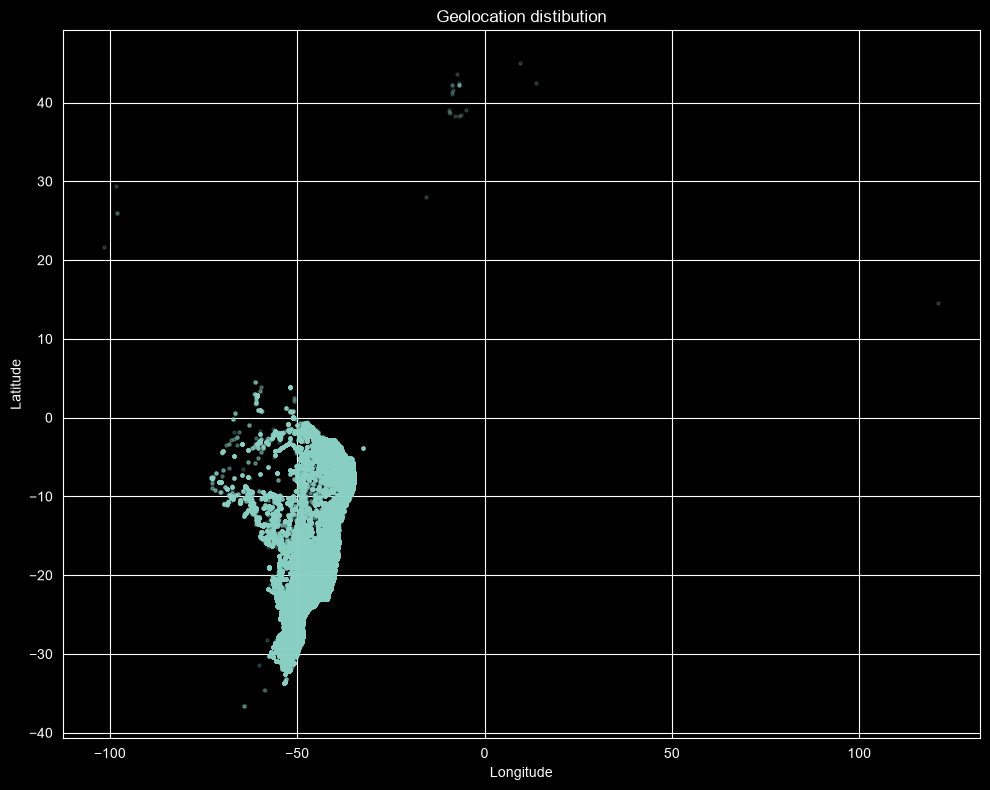

In [13]:
plt.figure(figsize=(10, 8))

plt.scatter(
    df["geolocation_lng"],
    df["geolocation_lat"],
    alpha=0.2,
    s=5
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geolocation distibution")

plt.tight_layout()
plt.show()